# Ex14 a: stock market prediction the completely wrong way 

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/tf2.0/sbux.csv')
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,27.920,28.325,27.920,28.185,7146296,SBUX
1,2013-02-11,28.260,28.260,27.930,28.070,5457354,SBUX
2,2013-02-12,28.000,28.275,27.975,28.130,8665592,SBUX
3,2013-02-13,28.230,28.230,27.750,27.915,7022056,SBUX
4,2013-02-14,27.765,27.905,27.675,27.775,8899188,SBUX


In [3]:
series = df['close']
print(series[:5])

0    28.185
1    28.070
2    28.130
3    27.915
4    27.775
Name: close, dtype: float64


In [4]:
D = 1
T = 20
K = 1
M = 128
L = 2

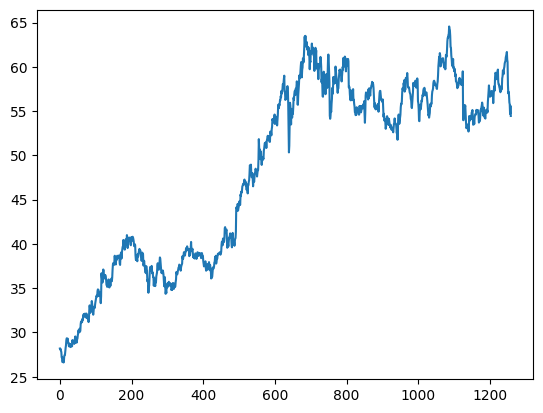

In [5]:
plt.plot(series)

## create data

In [6]:
scaler=StandardScaler()
N = len(series)
series = series.values.reshape(-1,1)
scaler.fit(series[:N//2])
series = scaler.transform(series).flatten()

In [7]:
X,y =[],[]
for t in range(N- T):
    X.append(series[t:t+T])
    y.append(series[t+T])

In [8]:
N = len(X)
print(N)


1239


In [9]:
X_train,X_test =np.array(X[:N//2]),np.array(X[N//2:])
y_train,y_test = y[:N//2],y[N//2:]
y_test = np.array(y_test).reshape(-1,K)
y_train = np.array(y_train).reshape(-1,K)

In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [11]:
X_train = torch.from_numpy(X_train.astype(np.float32))
X_test = torch.from_numpy(X_test.astype(np.float32))
y_train = torch.from_numpy(y_train.astype(np.float32)).to(device)
y_test = torch.from_numpy(y_test.astype(np.float32)).to(device)

## Model

In [12]:
class LSTMModel(nn.Module):
    def __init__(self,input_size,hidden_size,num_layers,output_size):
        super().__init__()
        self.D = input_size
        self.M = hidden_size
        self.L = num_layers
        self.K = output_size

        self.rnn = nn.LSTM(input_size=self.D,
                           hidden_size=self.M,
                           num_layers=self.L,
                           batch_first=True,
                           bidirectional=True)
        self.fc = nn.Linear(self.M*2,self.K)
    
    def forward(self,X):
        h0 = torch.zeros(self.L*2,X.size(0),self.M).to(device)
        c0 = torch.zeros(self.L*2,X.size(0),self.M).to(device)

        output,(h_n,c_n) = self.rnn(X,(h0,c0))
        output = self.fc(output[:,-1,:])
        return output 
        


In [13]:
lstm = LSTMModel(D,M,L,K).to(device)
optimizer = torch.optim.Adam(lstm.parameters(),lr=0.01)
criterion = nn.MSELoss().to(device)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,'min',patience=10)

training

In [14]:
epochs = 1000

In [15]:
def single_epoch(model,optimizer: torch.optim.Optimizer,criterion: nn.Module,X,y,is_training=True):


    input = X.view(-1,T,D).to(device)
    y_hat = model(input)
    loss = criterion(y_hat,y)

    if is_training:
        loss.backward()
        optimizer.step()
        scheduler.step(loss)
    
    return y_hat,loss.item()

    

In [16]:
train_losses = []
test_losses = []

for epoch in range(epochs):
    optimizer.zero_grad()
    _,train_loss = single_epoch(lstm,optimizer,criterion,X_train,y_train,True)
    _,test_loss = single_epoch(lstm,optimizer,criterion,X_test,y_test,False)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    print(f'{epoch}/{epochs} train loss {train_losses[-1]} test loss {test_losses[-1]}')

0/1000 train loss 1.0177124738693237 test loss 2.5866923332214355
1/1000 train loss 0.523566484451294 test loss 1.0033295154571533
2/1000 train loss 0.6545652151107788 test loss 0.4686731696128845
3/1000 train loss 0.2615496516227722 test loss 1.3312557935714722
4/1000 train loss 0.2769455909729004 test loss 1.5114997625350952
5/1000 train loss 0.2531159818172455 test loss 1.3718390464782715
6/1000 train loss 0.20344626903533936 test loss 1.0698657035827637
7/1000 train loss 0.13510750234127045 test loss 0.7257691621780396
8/1000 train loss 0.08682923763990402 test loss 0.4527161419391632
9/1000 train loss 0.10185480862855911 test loss 0.33774158358573914
10/1000 train loss 0.12183827906847 test loss 0.38332104682922363
11/1000 train loss 0.07166851311922073 test loss 0.4758496582508087
12/1000 train loss 0.062111999839544296 test loss 0.57979816198349
13/1000 train loss 0.057406164705753326 test loss 0.6624946594238281
14/1000 train loss 0.05306181684136391 test loss 0.697552978992462

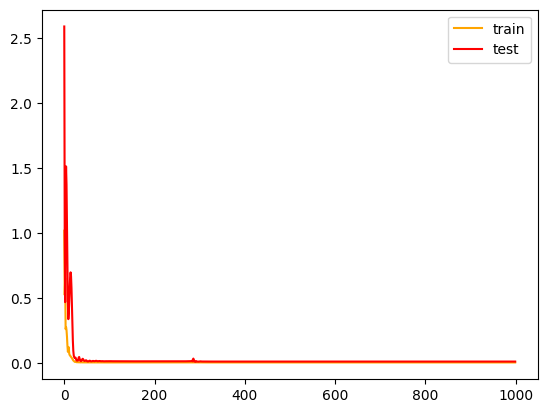

In [17]:
plt.plot(train_losses,color='orange',label='train')
plt.plot(test_losses,color='red',label='test')
plt.legend()
plt.show()

In [18]:
inps = X_test.view(-1,T,D).to(device)
y_hats = lstm(inps)

In [19]:
y_hats = y_hats.detach().cpu().numpy()

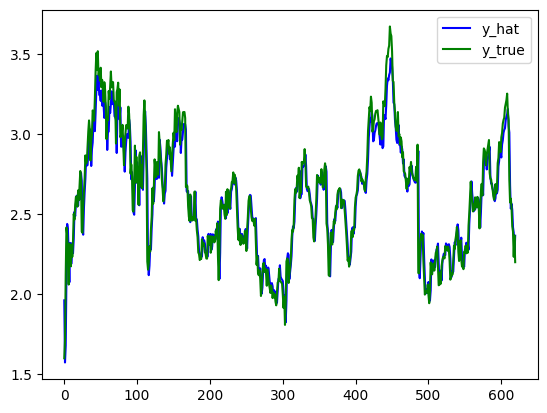

In [20]:
plt.plot(y_hats,label='y_hat',color='blue')
plt.plot(y_test.detach().cpu().numpy(),label='y_true',color='green')
plt.legend()
plt.show()

notice the problems in this methodology.
true it looks impressive
but
1. notice instead of starting with X_test we continously using it instead of using our predicted data thus each prediction is somewhat stray from the original because the trend is given. instead if we take X_test and join with our predictions and eventually base only upon our predictions it will be correct forecasting.

2. to claim that a single value can prophisied the whole geopolitical system sounds absurd, and if it was true the stock market would've broken by data scientists by now



## let's forecast the right way

In [21]:
y_hats = []
X_last = inps[0]

for i in range(y_test.shape[0]):
    y_hat,_ = single_epoch(lstm,optimizer,criterion,X_last,y_test[i],False)
    y_hats.append(y_hat.item())
    print('pre',X_last)
    X_last = torch.cat((X_last[1:],y_hat))
    print('post',X_last)
    

pre 

c:\Users\liora\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\loss.py:610: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


tensor([[2.5677],
        [2.5910],
        [2.6449],
        [2.7250],
        [2.7060],
        [2.7439],
        [2.8181],
        [2.8633],
        [2.6041],
        [2.5997],
        [2.4643],
        [2.4760],
        [2.4803],
        [2.5488],
        [2.5852],
        [2.6784],
        [2.6915],
        [2.6565],
        [2.3973],
        [1.9649]], device='cuda:0')
post tensor([[2.5910],
        [2.6449],
        [2.7250],
        [2.7060],
        [2.7439],
        [2.8181],
        [2.8633],
        [2.6041],
        [2.5997],
        [2.4643],
        [2.4760],
        [2.4803],
        [2.5488],
        [2.5852],
        [2.6784],
        [2.6915],
        [2.6565],
        [2.3973],
        [1.9649],
        [1.9624]], device='cuda:0', grad_fn=<CatBackward0>)
pre tensor([[2.5910],
        [2.6449],
        [2.7250],
        [2.7060],
        [2.7439],
        [2.8181],
        [2.8633],
        [2.6041],
        [2.5997],
        [2.4643],
        [2.4760],
        [2.48

In [22]:
ys = y_test.detach().cpu().numpy()

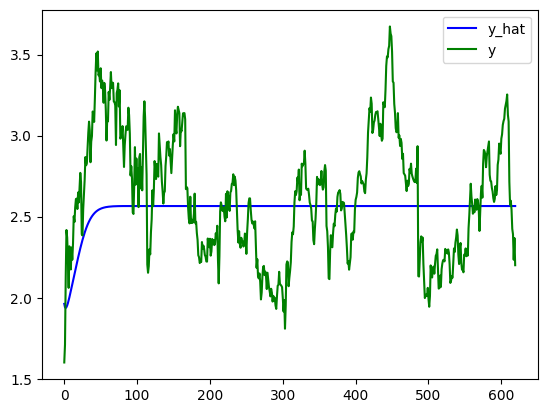

In [23]:

plt.plot(y_hats,color='blue',label='y_hat')
plt.plot(ys,color='green',label='y')
plt.legend()
plt.show()